Mounted at /content/drive
Train sequence shape: (333929, 6, 24) (333929,)
Val sequence shape  : (47264, 6, 24) (47264,)
Test sequence shape : (94644, 6, 24) (94644,)
Class weight: {0: 1.0, 1: 43.04233711421789}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        17,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,393 (75.75 KB)

 Trainable params: 19,393 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.7353 - loss: 1.0848 - val_accuracy: 0.7684 - val_loss: 0.4993
Epoch 2/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7409 - loss: 0.9603 - val_accuracy: 0.7522 - val_loss: 0.4705
Epoch 3/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.7485 - loss: 0.8716 - val_accuracy: 0.7578 - val_loss: 0.4437
Epoch 4/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7660 - loss: 0.7778 - val_accuracy: 0.7632 - val_loss: 0.4363
Epoch 5/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.7807 - loss: 0.7097 - val_accuracy: 0.7925 - val_loss: 0.4038
Epoch 6/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7937 - loss: 0.6506 - val_accuracy: 0.7844 - val_loss: 0.4108
Epoch 7/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8106 - loss: 0.6013 - val_accuracy: 0.8035 - val_loss: 0.4036
Epoch 8/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8267 - loss: 0

,Model,Accuracy,Precision,Recall,F1-score,AUROC,AUPRC
0,GRU,0.855606,0.075398,0.465509,0.129776,0.741697,0.068236


Classification Report:


,precision,recall,f1-score,support
0,0.985579,0.864842,0.921272,92455.000000
1,0.075398,0.465509,0.129776,2189.000000
accuracy,0.855606,0.855606,0.855606,0.855606
macro avg,0.530488,0.665176,0.525524,94644.000000
weighted avg,0.964527,0.855606,0.902965,94644.000000


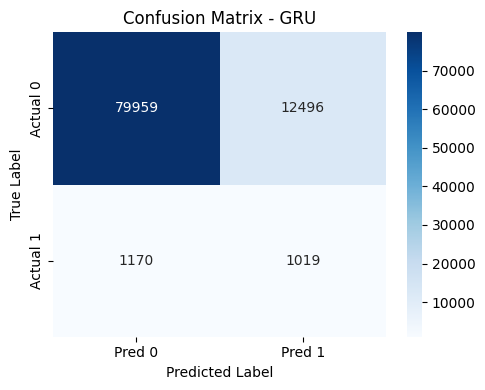

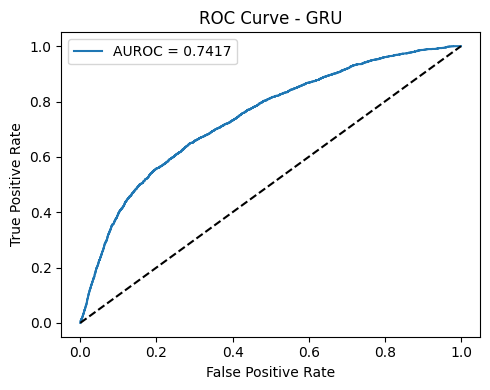

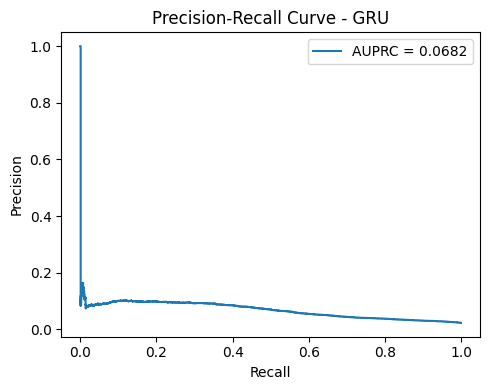

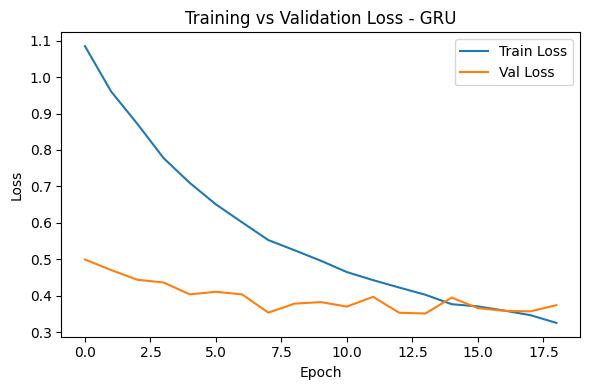

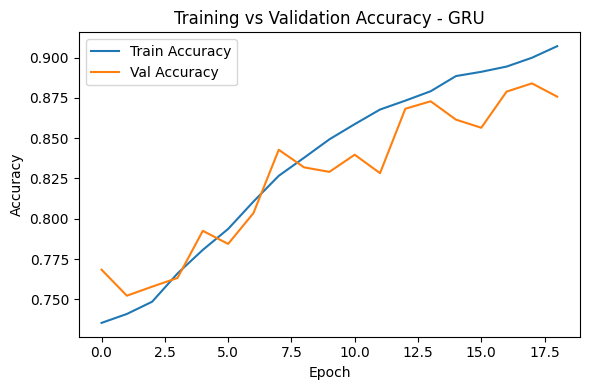


All outputs saved successfully in:
/content/drive/MyDrive/datamining/results/model_5_gru

Status marked as DONE.


In [1]:
# ==========================================
# MODEL 5: GRU
# SAVE EVERYTHING TO DRIVE + RESUME SUPPORT
# ==========================================

# 1) Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Install if needed
# If tensorflow is not installed in your Colab, uncomment the next line:
# !pip install tensorflow -q

# 3) Imports
import os
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 4) Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 5) Paths
base_dir = "/content/drive/MyDrive/datamining"
data_path = os.path.join(base_dir, "Dataset.csv")
save_dir = os.path.join(base_dir, "results", "model_5_gru")
os.makedirs(save_dir, exist_ok=True)

status_file = os.path.join(save_dir, "status.txt")

# 6) Skip if already done
if os.path.exists(status_file):
    with open(status_file, "r") as f:
        status = f.read().strip()
    if status == "DONE":
        print("Model 5 already completed. Files are saved in Drive:")
        print(save_dir)
        raise SystemExit

# 7) Load dataset
df = pd.read_csv(data_path)

# 8) Basic cleaning
drop_cols = ["Unnamed: 0", "EtCO2"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df = df.dropna(subset=["SepsisLabel", "Patient_ID"])
df = df.sort_values(["Patient_ID", "Hour"]).reset_index(drop=True)

# 9) Drop very high missing columns (>90%), but keep some important clinical columns
missing_percent = df.isnull().mean() * 100
important_keep = ["Lactate", "Platelets", "Creatinine", "WBC"]
high_missing_cols = missing_percent[missing_percent > 90].index.tolist()
high_missing_cols = [
    c for c in high_missing_cols
    if c not in important_keep and c not in ["SepsisLabel", "Patient_ID", "Hour"]
]
df = df.drop(columns=high_missing_cols)

pd.DataFrame({"dropped_columns": high_missing_cols}).to_csv(
    os.path.join(save_dir, "dropped_columns.csv"), index=False
)

# 10) Patient-wise forward fill
exclude_ffill = ["SepsisLabel", "Patient_ID", "Hour"]
ffill_cols = [c for c in df.columns if c not in exclude_ffill]
df[ffill_cols] = df.groupby("Patient_ID")[ffill_cols].ffill()

# 11) Feature / target
target_col = "SepsisLabel"
group_col = "Patient_ID"
time_col = "Hour"
feature_cols = [c for c in df.columns if c not in [target_col, group_col]]

# 12) Patient-wise split: train / val / test
patient_df = df[[group_col, target_col]].groupby(group_col)[target_col].max().reset_index()

train_patients, test_patients = train_test_split(
    patient_df,
    test_size=0.2,
    random_state=42,
    stratify=patient_df[target_col]
)

train_patients, val_patients = train_test_split(
    train_patients,
    test_size=0.125,   # 0.125 of 0.8 = 0.1 => total 70/10/20 approx
    random_state=42,
    stratify=train_patients[target_col]
)

train_ids = set(train_patients[group_col])
val_ids   = set(val_patients[group_col])
test_ids  = set(test_patients[group_col])

train_df = df[df[group_col].isin(train_ids)].copy()
val_df   = df[df[group_col].isin(val_ids)].copy()
test_df  = df[df[group_col].isin(test_ids)].copy()

# 13) Save split info
split_info = {
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "train_patients": int(len(train_ids)),
    "val_patients": int(len(val_ids)),
    "test_patients": int(len(test_ids)),
    "n_features": int(len(feature_cols))
}
with open(os.path.join(save_dir, "split_info.json"), "w") as f:
    json.dump(split_info, f, indent=2)

# 14) Median imputation (fit only on train)
imputer = SimpleImputer(strategy="median")

X_train_tab = pd.DataFrame(imputer.fit_transform(train_df[feature_cols]), columns=feature_cols, index=train_df.index)
X_val_tab   = pd.DataFrame(imputer.transform(val_df[feature_cols]), columns=feature_cols, index=val_df.index)
X_test_tab  = pd.DataFrame(imputer.transform(test_df[feature_cols]), columns=feature_cols, index=test_df.index)

joblib.dump(imputer, os.path.join(save_dir, "imputer.pkl"))

# 15) Scaling (fit only on train)
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_tab), columns=feature_cols, index=train_df.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_tab), columns=feature_cols, index=val_df.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_tab), columns=feature_cols, index=test_df.index)

joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))

# Rebuild dfs with scaled features
train_df_seq = train_df[[group_col, time_col, target_col]].copy()
val_df_seq   = val_df[[group_col, time_col, target_col]].copy()
test_df_seq  = test_df[[group_col, time_col, target_col]].copy()

for col in feature_cols:
    train_df_seq[col] = X_train_scaled[col].values
    val_df_seq[col]   = X_val_scaled[col].values
    test_df_seq[col]  = X_test_scaled[col].values

# 16) Create patient-wise sequences
WINDOW = 6

def make_sequences(dataframe, feature_cols, target_col="SepsisLabel", patient_col="Patient_ID", time_col="Hour", window=6):
    X_seq, y_seq, meta = [], [], []

    dataframe = dataframe.sort_values([patient_col, time_col]).reset_index(drop=True)

    for pid, group in dataframe.groupby(patient_col):
        group = group.sort_values(time_col).reset_index(drop=True)

        if len(group) < window:
            continue

        features = group[feature_cols].values
        labels = group[target_col].astype(int).values
        hours = group[time_col].values

        for i in range(window - 1, len(group)):
            seq_x = features[i - window + 1:i + 1]
            seq_y = labels[i]

            X_seq.append(seq_x)
            y_seq.append(seq_y)
            meta.append({
                "Patient_ID": pid,
                "Hour": hours[i]
            })

    X_seq = np.array(X_seq, dtype=np.float32)
    y_seq = np.array(y_seq, dtype=np.int32)
    meta_df = pd.DataFrame(meta)

    return X_seq, y_seq, meta_df

X_train_seq, y_train_seq, train_meta = make_sequences(train_df_seq, feature_cols, window=WINDOW)
X_val_seq, y_val_seq, val_meta       = make_sequences(val_df_seq, feature_cols, window=WINDOW)
X_test_seq, y_test_seq, test_meta    = make_sequences(test_df_seq, feature_cols, window=WINDOW)

print("Train sequence shape:", X_train_seq.shape, y_train_seq.shape)
print("Val sequence shape  :", X_val_seq.shape, y_val_seq.shape)
print("Test sequence shape :", X_test_seq.shape, y_test_seq.shape)

# Save sequence info
seq_info = {
    "window_size": WINDOW,
    "train_sequences": int(len(X_train_seq)),
    "val_sequences": int(len(X_val_seq)),
    "test_sequences": int(len(X_test_seq))
}
with open(os.path.join(save_dir, "sequence_info.json"), "w") as f:
    json.dump(seq_info, f, indent=2)

# 17) Class weights
neg = int((y_train_seq == 0).sum())
pos = int((y_train_seq == 1).sum())

if pos > 0:
    class_weight = {
        0: 1.0,
        1: neg / pos
    }
else:
    class_weight = {0: 1.0, 1: 1.0}

print("Class weight:", class_weight)

# 18) Build GRU model
model = Sequential([
    GRU(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

best_model_path = os.path.join(save_dir, "best_gru_model.keras")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True
    )
]

# 19) Train
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=128,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

# Save final model
model.save(os.path.join(save_dir, "gru_model.keras"))

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join(save_dir, "training_history.csv"), index=False)

# 20) Predict
y_prob = model.predict(X_test_seq, batch_size=256).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# 21) Metrics
acc   = accuracy_score(y_test_seq, y_pred)
prec  = precision_score(y_test_seq, y_pred, zero_division=0)
rec   = recall_score(y_test_seq, y_pred, zero_division=0)
f1    = f1_score(y_test_seq, y_pred, zero_division=0)
auroc = roc_auc_score(y_test_seq, y_prob)
auprc = average_precision_score(y_test_seq, y_prob)

metrics_df = pd.DataFrame([{
    "Model": "GRU",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1-score": f1,
    "AUROC": auroc,
    "AUPRC": auprc
}])

print("\nFinal Metrics:")
display(metrics_df)
metrics_df.to_csv(os.path.join(save_dir, "metrics.csv"), index=False)

# 22) Classification report
report_dict = classification_report(y_test_seq, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
print("Classification Report:")
display(report_df)
report_df.to_csv(os.path.join(save_dir, "classification_report.csv"))

# 23) Save predictions with meta
pred_df = test_meta.copy()
pred_df["y_true"] = y_test_seq
pred_df["y_pred"] = y_pred
pred_df["y_prob"] = y_prob
pred_df.to_csv(os.path.join(save_dir, "predictions.csv"), index=False)

# 24) Confusion Matrix
cm = confusion_matrix(y_test_seq, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix - GRU")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 25) ROC curve
fpr, tpr, _ = roc_curve(y_test_seq, y_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "roc_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 26) Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test_seq, y_prob)

plt.figure(figsize=(5,4))
plt.plot(recall_vals, precision_vals, label=f"AUPRC = {auprc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - GRU")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "pr_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 27) Training curves
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss - GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy - GRU")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 28) Mark as done
with open(status_file, "w") as f:
    f.write("DONE")

print("\nAll outputs saved successfully in:")
print(save_dir)
print("\nStatus marked as DONE.")